In [2]:
import pandas as pd

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_excel("amazon.xlsx")

In [ ]:
df.shape

(100000, 20)

In [ ]:
df.columns


Index(['OrderID', 'OrderDate', 'CustomerID', 'CustomerName', 'ProductID',
       'ProductName', 'Category', 'Brand', 'Quantity', 'UnitPrice', 'Discount',
       'Tax', 'ShippingCost', 'TotalAmount', 'PaymentMethod', 'OrderStatus',
       'City', 'State', 'Country', 'SellerID'],
      dtype='object')

In [ ]:
df.dtypes

,0
OrderID,object
OrderDate,datetime64[ns]
CustomerID,object
CustomerName,object
ProductID,object
ProductName,object
Category,object
Brand,object
Quantity,int64
UnitPrice,float64


In [ ]:
df.describe()

,OrderDate,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount
count,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,2022-06-30 23:55:49.440000,3.001400,302.905748,0.074226,68.468902,7.406660,918.256479
min,2020-01-01 00:00:00,1.000000,5.000000,0.000000,0.000000,0.000000,4.270000
25%,2021-04-01 00:00:00,2.000000,154.190000,0.000000,15.920000,3.680000,340.890000
50%,2022-07-01 00:00:00,3.000000,303.070000,0.050000,45.250000,7.300000,714.315000
75%,2023-09-29 00:00:00,4.000000,451.500000,0.100000,96.060000,11.150000,1349.765000
max,2024-12-29 00:00:00,5.000000,599.990000,0.300000,538.460000,15.000000,3534.980000
std,NaN,1.413548,171.840797,0.082583,74.131180,4.324057,724.508332


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   OrderID        100000 non-null  object        
 1   OrderDate      100000 non-null  datetime64[ns]
 2   CustomerID     100000 non-null  object        
 3   CustomerName   100000 non-null  object        
 4   ProductID      100000 non-null  object        
 5   ProductName    100000 non-null  object        
 6   Category       100000 non-null  object        
 7   Brand          100000 non-null  object        
 8   Quantity       100000 non-null  int64         
 9   UnitPrice      100000 non-null  float64       
 10  Discount       100000 non-null  float64       
 11  Tax            100000 non-null  float64       
 12  ShippingCost   100000 non-null  float64       
 13  TotalAmount    100000 non-null  float64       
 14  PaymentMethod  100000 non-null  object        
 15  O

In [ ]:
#KPI analysis
##Total sales
df['TotalAmount'].sum()

np.float64(91825647.92)

In [ ]:
##•	Total Orders
df['OrderID'].count()

np.int64(100000)

In [ ]:
##	Average Sales
df['TotalAmount'].mean()

np.float64(918.2564792000001)

In [ ]:
##	Maximum Sales
df['TotalAmount'].max()

3534.98

In [ ]:
##	Minimum Sales
df['TotalAmount'].min()

4.27

In [ ]:
#revenue by state
df.groupby("State")["TotalAmount"].sum().sort_values(ascending=False)

,TotalAmount
State,
TX,22862540.54
CA,18231196.79
NC,4747701.73
WA,4660962.17
PA,4650673.88
CO,4638498.97
IL,4632847.44
OH,4615442.32
IN,4609048.43


In [ ]:
#revenue by Category
df.groupby("Category")["TotalAmount"].sum()

,TotalAmount
Category,
Books,15261837.01
Clothing,15253397.50
Electronics,15584217.18
Home & Kitchen,15163939.36
Sports & Outdoors,15345571.88
Toys & Games,15216684.99


In [ ]:
#top 5 customers
df.groupby("CustomerName")["TotalAmount"].sum().sort_values(ascending=False).head(5)

,TotalAmount
CustomerName,
Pooja Kapoor,547832.64
Vihaan Singh,526675.89
Pooja Singh,516451.45
Kabir Joshi,515361.68
Aditya Gupta,515005.09


In [ ]:
##total quantity for each product
df.groupby("ProductID")["Quantity"].sum()

,Quantity
ProductID,
P00001,6008
P00002,5782
P00003,6060
P00004,5811
P00005,5992
P00006,6170
P00007,6161
P00008,6111
P00009,5996


In [ ]:
##total orders for each payment method
df.groupby("PaymentMethod")["OrderID"].count()

,OrderID
PaymentMethod,
Amazon Pay,15017
Cash on Delivery,4928
Credit Card,35038
Debit Card,20024
Net Banking,9927
UPI,15066


In [8]:
## monthly sales trend using the Order Date column
df["OrderDate"] = pd.to_datetime(df["OrderDate"])
df["Month"] = df["OrderDate"].dt.to_period("M")
df.groupby("Month")["TotalAmount"].sum()



,TotalAmount
Month,
2020-01,1637069.40
2020-02,1339388.21
2020-03,1587125.66
2020-04,1588347.29
2020-05,1533834.17
2020-06,1500269.29
2020-07,1552981.94
2020-08,1640874.93
2020-09,1554682.21


In [ ]:
##sales generated by each State for every Category

df.groupby(["State", "Category"]).agg({
    "TotalAmount": "sum"
})

TotalAmount
State Category                      
AZ    Books                793211.33
      Clothing             691249.82
      Electronics          747955.37
      Home & Kitchen       737616.34
      Sports & Outdoors    694318.06
...                              ...
WA    Clothing             747668.70
      Electronics          879580.90
      Home & Kitchen       809448.28
      Sports & Outdoors    807282.60
      Toys & Games         711514.12

[78 rows x 1 columns]

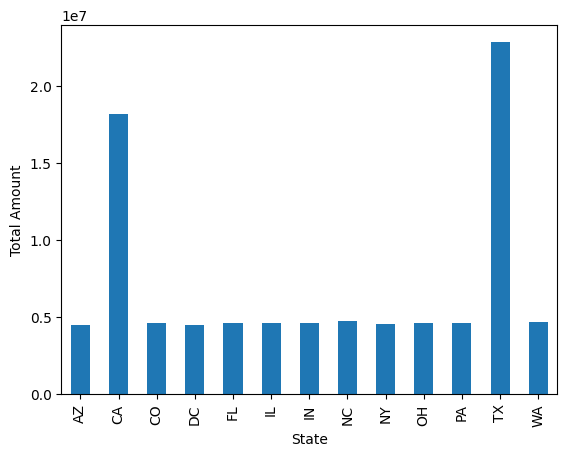

In [5]:
#bar chart showing sales by state

df.groupby("State")["TotalAmount"].sum().plot(kind="bar")
plt.xlabel("State")
plt.ylabel("Total Amount")
plt.show()

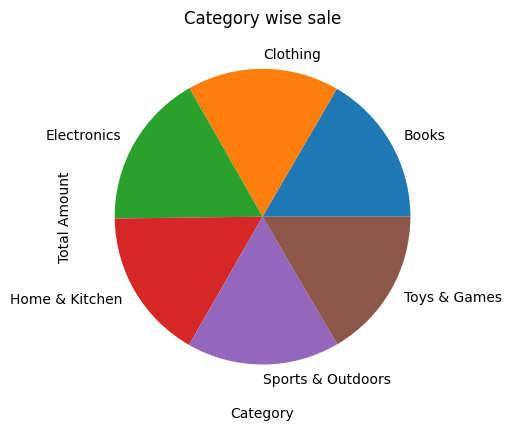

In [14]:
#PIE chart showing Catergory wise sale

df.groupby("Category")["TotalAmount"].sum().plot(kind="pie")
plt.title("Category wise sale")
plt.xlabel("Category")
plt.ylabel("Total Amount")
plt.show()

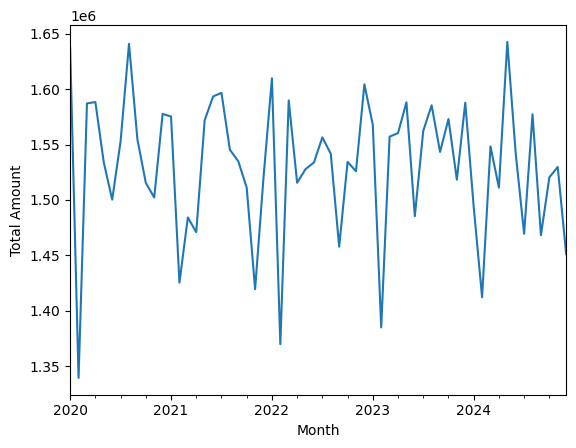

In [9]:
#line chart showing monthly sales trend

df.groupby("Month")["TotalAmount"].sum().plot(kind="line")
plt.xlabel("Month")
plt.ylabel("Total Amount")
plt.show()

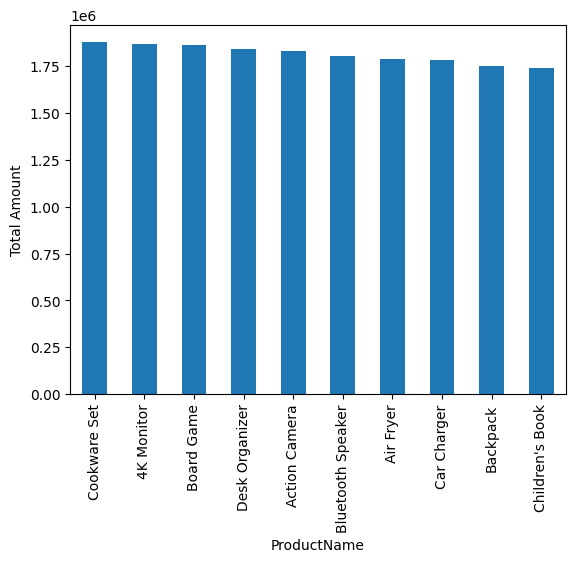

In [13]:
#Horizontal Bar Chart showing the Top 10 Products by Sales.

df.groupby("ProductName")["TotalAmount"].sum().head(10).sort_values(ascending=False).plot(kind="bar")
plt.xlabel("ProductName")
plt.ylabel("Total Amount")
plt.show()

In [18]:
##Business Questions
#What is the total sales and average order value?
Total_sales = df['TotalAmount'].sum()
print("Total sales:", Total_sales)

Total sales: 91825647.92


In [17]:
average_order_value = df["TotalAmount"].mean()
print("Average Order Value:", average_order_value)

Average Order Value: 918.2564792000001


In [19]:
#Which state generated the highest and the lowest sales?
highest_sales_state = df.groupby("State")["TotalAmount"].sum().idxmax()
print("State with the highest sales:", highest_sales_state)

State with the highest sales: TX


In [20]:
lowest_sales_state = df.groupby("State")["TotalAmount"].sum().idxmin()
print("State with the lowest sales:", lowest_sales_state)

State with the lowest sales: AZ


In [21]:
#Which category contributed the highest revenue?
highest_revenue_category = df.groupby("Category")["TotalAmount"].sum().idxmax()
print("Category with the highest revenue:", highest_revenue_category)

Category with the highest revenue: Electronics


In [ ]:
#Which are the Top 10 products based on sales?


In [22]:
Top_10_products = df.groupby("ProductName")["TotalAmount"].sum().sort_values(ascending=False).head(10)
print("Top 10 products based on sales:",Top_10_products)

Top 10 products based on sales: ProductName
Memory Card 128GB      1935138.40
LED Desk Lamp          1921948.41
Mechanical Keyboard    1906963.54
Electric Kettle        1905751.79
Smartwatch             1901275.59
Dress Shirt            1896765.36
Water Bottle           1895467.95
Gaming Mouse           1895103.98
Kids Toy Car           1891082.43
Jeans                  1882591.82
Name: TotalAmount, dtype: float64


In [23]:
#Who are the Top 5 customers contributing the highest revenue?
Top_5_customers = df.groupby("CustomerName")["TotalAmount"].sum().sort_values(ascending=False).head(5)
print("Top 5 customers contributing the highest revenue:",Top_5_customers)

Top 5 customers contributing the highest revenue: CustomerName
Pooja Kapoor    547832.64
Vihaan Singh    526675.89
Pooja Singh     516451.45
Kabir Joshi     515361.68
Aditya Gupta    515005.09
Name: TotalAmount, dtype: float64


In [26]:
#Which payment mode is most preferred by customers?
most_preferred_payment_mode = df["PaymentMethod"].value_counts().idxmax()
print("Most preferred payment mode by customers:",most_preferred_payment_mode)

Most preferred payment mode by customers: Credit Card


In [27]:
#Which month recorded the highest sales and profit? Is there any noticeable sales trend?
highest_sales_month = df.groupby("Month")["TotalAmount"].sum().idxmax()
print("Month with the highest sales:",highest_sales_month)

Month with the highest sales: 2024-05


In [5]:
#Which state or city requires improvement in sales performance? Suggest possible business strategies.
State_need_improvement = df.groupby("State")["TotalAmount"].sum().idxmin()
print("State with lowest sales that needs improvement:",State_need_improvement)

State with lowest sales that needs improvement: AZ


Suggest possible business strategies:-
Increase local marketing
 offer promotional discounts
 improve delivery services
 maintain adequate inventory
  introduce loyalty programs to boost sales and customer retention



Based complete analysis, provide three actionable business recommendations that Amazon's management can implement to improve sales and profitability:-


1.   Increase marketing efforts and promotional campaigns in low-performing states and cities to improve sales performance.
2.   Focus on expanding the availability and promotion of top-selling products and categories to maximize revenue.


1.   Optimize pricing, discounts, and operational costs while introducing customer loyalty programs to improve overall profitability and encourage repeat purchases.





